In [1]:
pip install tensorflow

In [4]:
pip install mnist

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

In [6]:
print("1. Loading the MNIST dataset...")
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

1. Loading the MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
X_train_n = X_train.astype("float32") / 255.0
X_val_n = X_val.astype("float32") / 255.0
X_test_n = X_test.astype("float32") / 255.0

In [8]:
from tensorflow.keras.utils import to_categorical
y_train_oh = to_categorical(y_train, 10)
y_val_oh = to_categorical(y_val, 10)
y_test_oh = to_categorical(y_test, 10)

In [9]:
X_train_n = np.expand_dims(X_train_n, axis=-1)
X_val_n = np.expand_dims(X_val_n, axis=-1)
X_test_n = np.expand_dims(X_test_n, axis=-1)

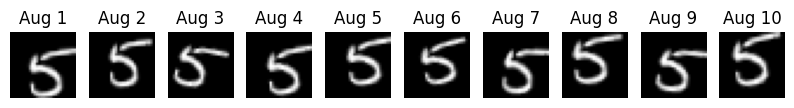

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

sample_img = X_train_n[0:1]
aug_iter = datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(10, 3))
for i in range(10):
  plt.subplot(1, 10, i + 1)
  batch = next(aug_iter)
  plt.imshow(batch[0].squeeze(), cmap='gray')
  plt.title(f"Aug {i+1}")
  plt.axis('off')
plt.show()

In [11]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_der(x):
  return x * (1 - x)

In [12]:
X_example = X_train_n[0].flatten().reshape(1, 784)
y_example = y_train_oh[0].reshape(1, 10)

In [13]:
weights = np.random.randn(784, 10) * 0.01
bias = np.zeros((1, 10))

In [14]:
z = np.dot(X_example, weights) + bias
output = sigmoid(z)

In [15]:
error = y_example - output
loss = np.mean(np.square(error))

In [16]:
d_output = error * sigmoid_der(output)
weights += np.dot(X_example.T, d_output) * 0.1

print(f"\nNumPy Example - Loss: {loss:.4f}")


NumPy Example - Loss: 0.2422


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

In [18]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train_n, y_train_oh,
    batch_size = 64,
    validation_data=(X_val_n, y_val_oh),
    epochs=5
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8387 - loss: 0.5763 - val_accuracy: 0.9459 - val_loss: 0.1903
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9516 - loss: 0.1665 - val_accuracy: 0.9603 - val_loss: 0.1356
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9658 - loss: 0.1178 - val_accuracy: 0.9657 - val_loss: 0.1145
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9749 - loss: 0.0824 - val_accuracy: 0.9688 - val_loss: 0.1031
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9811 - loss: 0.0645 - val_accuracy: 0.9717 - val_loss: 0.0965
